# DETEKSI KOMUNITAS FB

In [23]:
!pip install networkx matplotlib python-louvain


In [40]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from community import community_louvain


In [41]:
# Load dataset
file_path = "/content/facebook_combined.txt"   # sesuaikan lokasi upload
edges = pd.read_csv(file_path, sep=" ", header=None, names=["source", "target"])

edges.head()


,source,target
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


In [42]:
G = nx.from_pandas_edgelist(edges, "source", "target")
print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())


Jumlah node: 4039
Jumlah edge: 88234


In [43]:
# Langkah 1: Jalankan Louvain
partition_raw = community_louvain.best_partition(G)

# Konversi ke dataframe komunitas
df_com = pd.DataFrame({
    "node": list(partition_raw.keys()),
    "community": list(partition_raw.values())
})

# Group komunitas
groups = df_com.groupby("community")["node"].apply(list)

# Urutkan berdasarkan ukuran (besar -> kecil)
groups_sorted = groups.sort_values(key=lambda x: x.str.len(), ascending=False)

# Tentukan 13 komunitas utama
main_coms = groups_sorted[:13]

# Komunitas lain (kecil) akan digabung
other_coms = groups_sorted[13:]

print("Komunitas awal Louvain :", len(groups_sorted))
print("Komunitas target       : 13")
print("Komunitas kecil        :", len(other_coms))


Komunitas awal Louvain : 16
Komunitas target       : 13
Komunitas kecil        : 3


In [44]:
# Mapping baru: node -> komunitas_final (0..12)
final_partition = {}

# Assign 13 komunitas besar
for new_id, (c_id, nodes) in enumerate(main_coms.items()):
    for n in nodes:
        final_partition[n] = new_id

# Komunitas kecil digabung ke komunitas besar terdekat
for c_id, nodes in other_coms.items():

    for n in nodes:
        # Cari komunitas besar yang paling banyak terhubung
        neighbors = list(G.neighbors(n))

        # Hitung koneksi ke setiap komunitas besar
        count_per_com = {kid: 0 for kid in range(13)}
        for nbr in neighbors:
            if nbr in final_partition:
                count_per_com[final_partition[nbr]] += 1

        # Pilih komunitas dengan tetangga terbanyak
        best_com = max(count_per_com, key=count_per_com.get)
        final_partition[n] = best_com


In [45]:
community_df = (
    pd.DataFrame({"node": list(final_partition.keys()),
                  "community": list(final_partition.values())})
    .groupby("community")["node"]
    .apply(list)
    .reset_index(name="nodes")
)

community_df["size"] = community_df["nodes"].apply(len)

# Urutkan berdasarkan ukuran
community_df = community_df.sort_values(by="size", ascending=False)

community_df


,community,nodes,size
1,1,"[1684, 3173, 990, 1140, 1450, 1505, 1534, 1642...",554
0,0,"[1085, 3437, 3454, 3487, 3723, 3861, 3961, 857...",548
3,3,"[34, 173, 198, 348, 414, 428, 353, 363, 366, 3...",457
4,4,"[136, 1912, 1465, 1577, 1718, 1926, 1932, 1939...",442
2,2,"[107, 897, 899, 904, 906, 907, 911, 916, 918, ...",435
5,5,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",350
6,6,"[389, 896, 898, 902, 913, 914, 917, 919, 924, ...",323
7,7,"[2543, 2266, 2347, 2542, 2468, 1917, 1918, 192...",237
8,8,"[3304, 2663, 2664, 2666, 2669, 2673, 2676, 267...",226
9,9,"[686, 687, 688, 689, 690, 691, 692, 693, 694, ...",206


/tmp/ipython-input-2948718464.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_com)


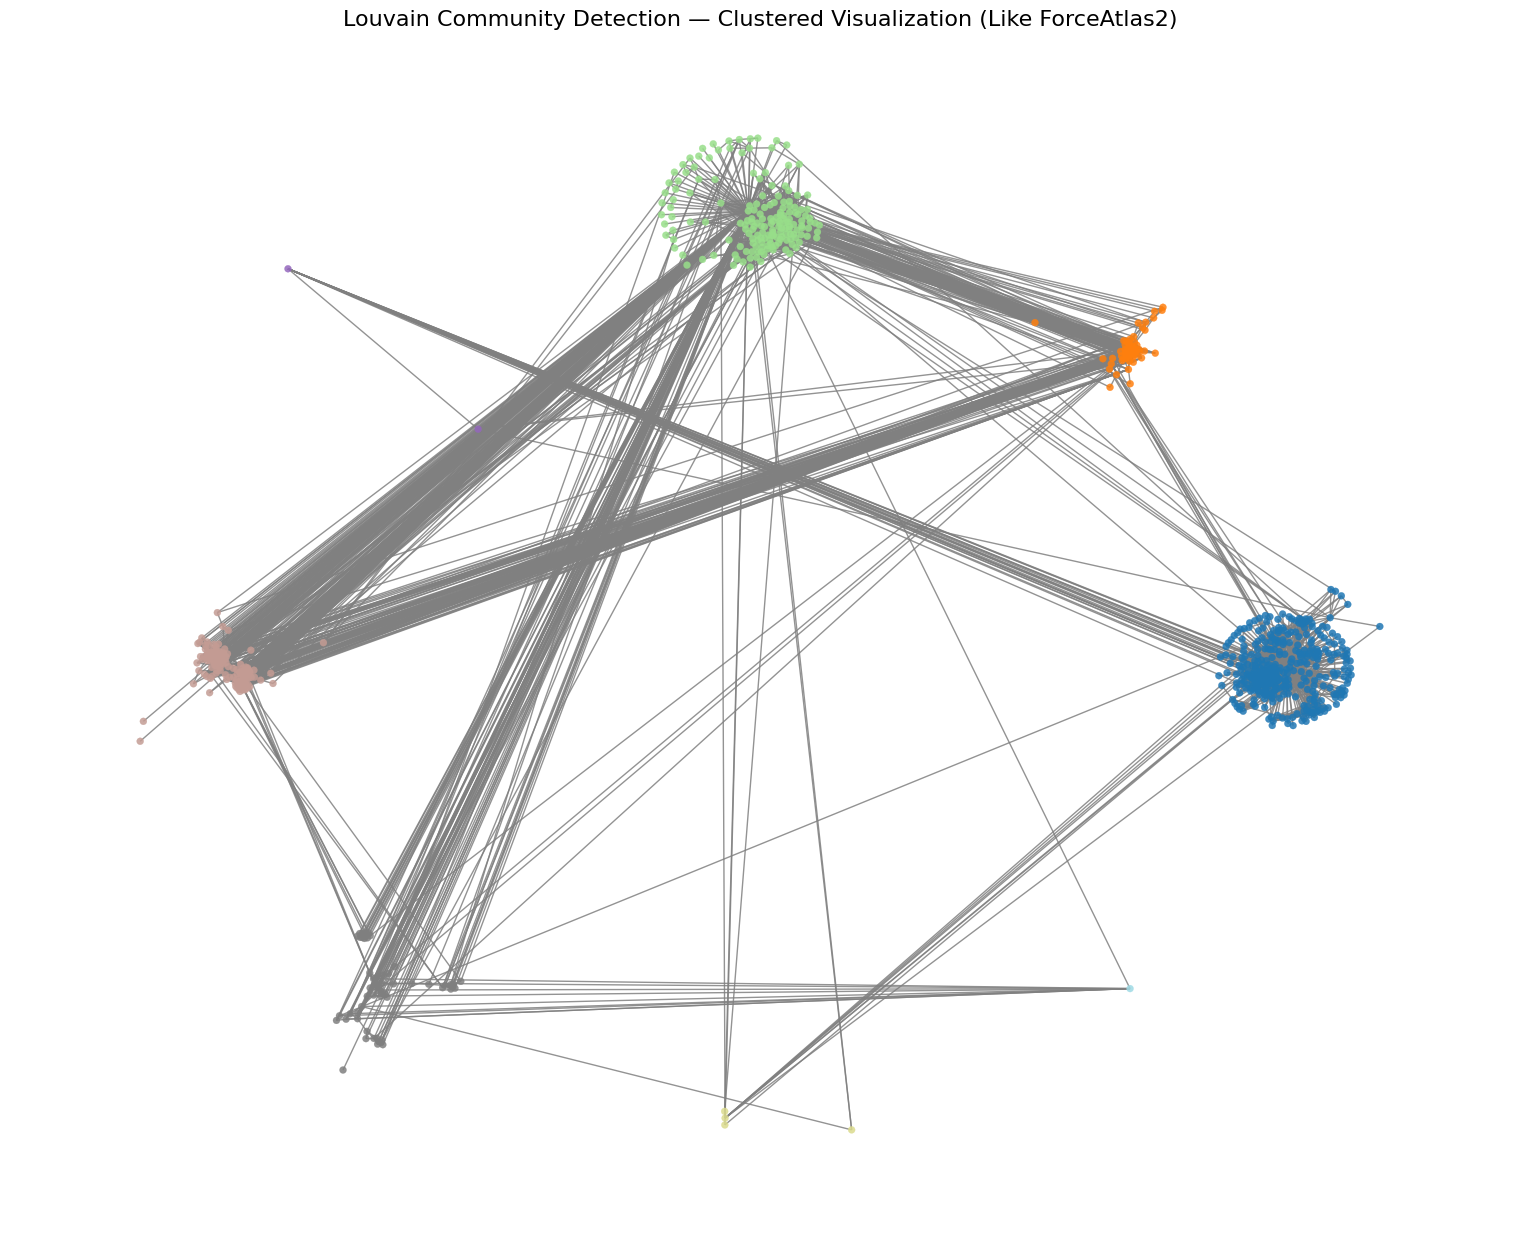

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ambil node untuk subgraph (agar tidak berat) ---
sample_nodes = list(G.nodes())[:800]  # bisa naikkan sampai 1500 jika kuat
H = G.subgraph(sample_nodes)

# --- Ambil komunitas dalam subgraph ---
community_nodes = {}
for n in H.nodes():
    com = final_partition[n]
    if com not in community_nodes:
        community_nodes[com] = []
    community_nodes[com].append(n)

num_com = len(community_nodes)

# --- Warna untuk setiap komunitas ---
cmap = plt.cm.get_cmap("tab20", num_com)
color_map = {com_id: cmap(i) for i, com_id in enumerate(community_nodes.keys())}

# --- Force-cluster layout mirip ForceAtlas2 ---
pos = {}
cluster_positions = {}

# posisi cluster global
angle_step = 2 * np.pi / num_com
radius = 5

for idx, com_id in enumerate(community_nodes.keys()):
    # posisi pusat cluster
    angle = idx * angle_step
    cx = radius * np.cos(angle)
    cy = radius * np.sin(angle)
    cluster_positions[com_id] = np.array([cx, cy])

    # layout internal cluster
    internal_pos = nx.spring_layout(
        H.subgraph(community_nodes[com_id]),
        seed=42,
        k=0.12,  # rapatkan cluster
        iterations=40
    )

    # geser layout internal ke posisi cluster
    for n, (x, y) in internal_pos.items():
        pos[n] = np.array([x, y]) * 0.9 + cluster_positions[com_id]

# --- Warna node ---
node_colors = [color_map[final_partition[n]] for n in H.nodes()]

# --- Gambar graph ---
plt.figure(figsize=(15, 12))

nx.draw(
    H,
    pos,
    node_size=25,
    node_color=node_colors,
    edge_color="gray",
    alpha=0.85,
    with_labels=False,
    linewidths=0.2
)

plt.title("Louvain Community Detection — Clustered Visualization (Like ForceAtlas2)", fontsize=16)
plt.axis("off")
plt.show()


In [50]:
community_df.to_csv("komunitas_13_fix.csv", index=False)
print("File komunitas_13_fix.csv berhasil disimpan.")


File komunitas_13_fix.csv berhasil disimpan.


Komunitas ID: 1
Jumlah node: 554


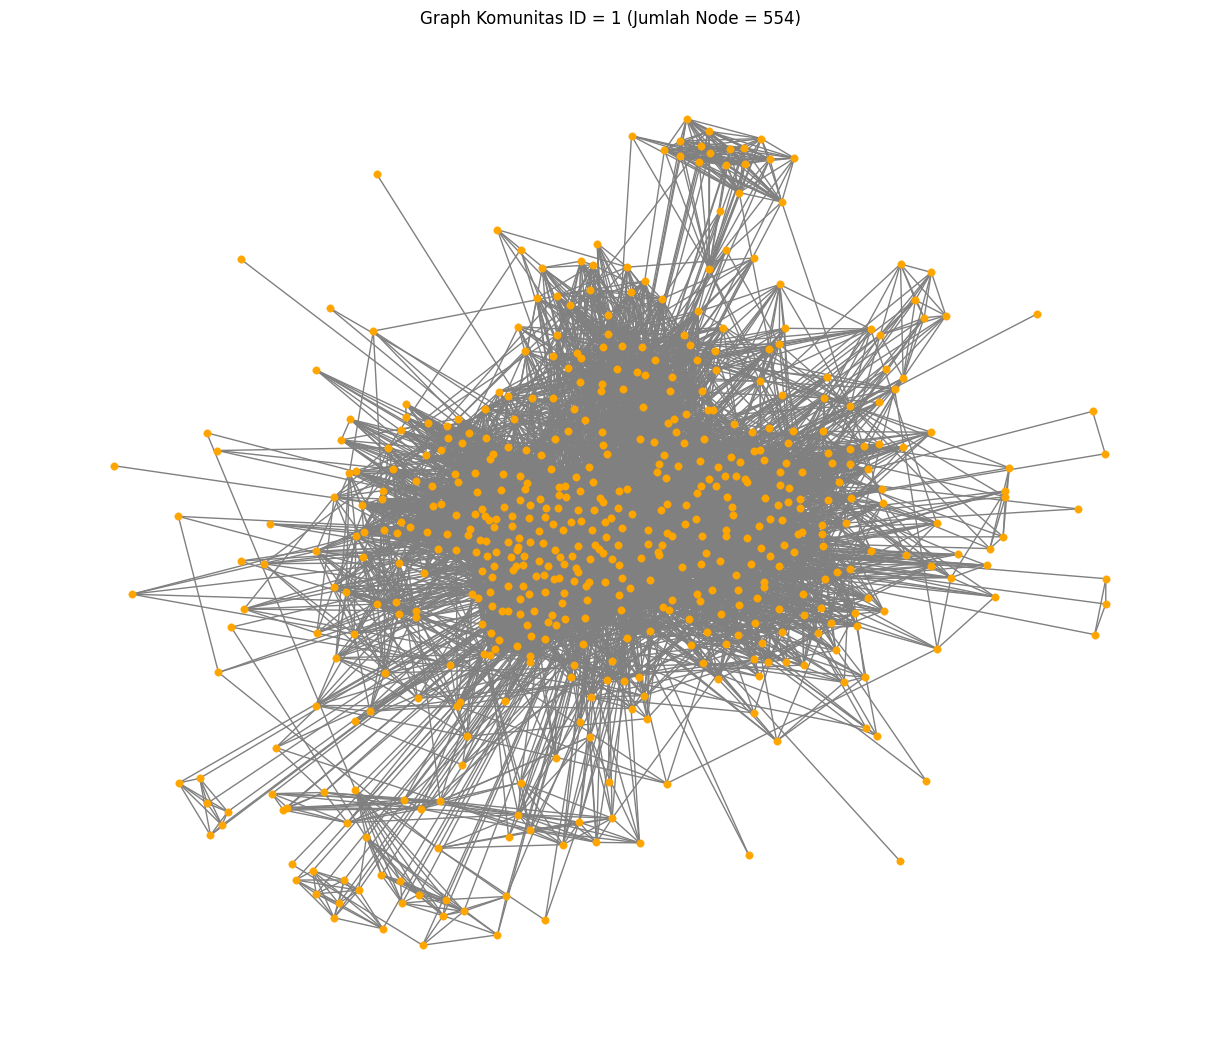

In [52]:
# --- Ambil node komunitas ID = 1 ---
community_id = 1

community_nodes_list = [
    n for n, com in final_partition.items() if com == community_id
]

print("Komunitas ID:", community_id)
print("Jumlah node:", len(community_nodes_list))

# --- Buat subgraph komunitas tersebut ---
H_com1 = G.subgraph(community_nodes_list)

# --- Layout komunitas ---
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(H_com1, seed=42, k=0.15, iterations=40)

# --- Warna komunitas 1 (warna bisa disesuaikan) ---
node_color = "orange"

nx.draw(
    H_com1,
    pos,
    node_size=30,
    node_color=node_color,
    edge_color="gray",
    linewidths=0.2,
    with_labels=False
)

plt.title(f"Graph Komunitas ID = {community_id} (Jumlah Node = {len(community_nodes_list)})")
plt.axis("off")
plt.show()
